# **CNN(Convolutional Neural Network)**

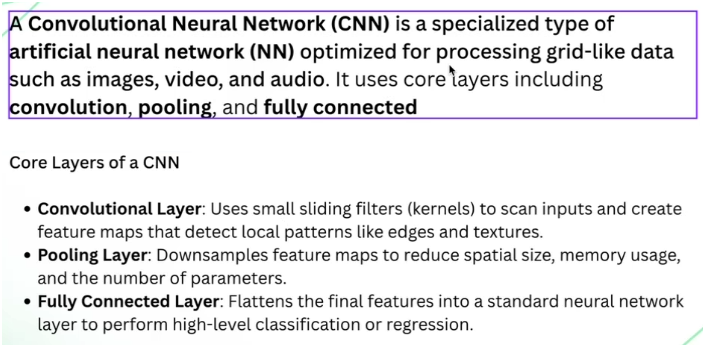

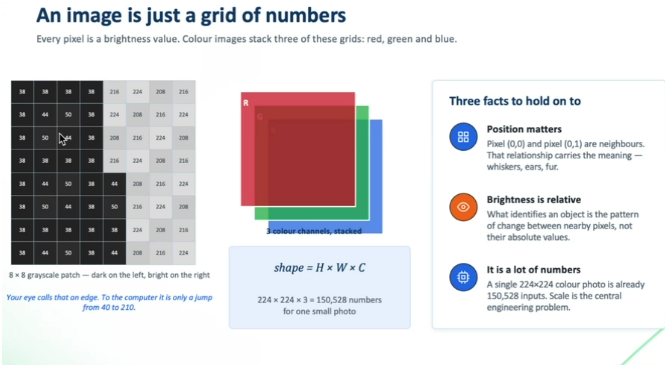

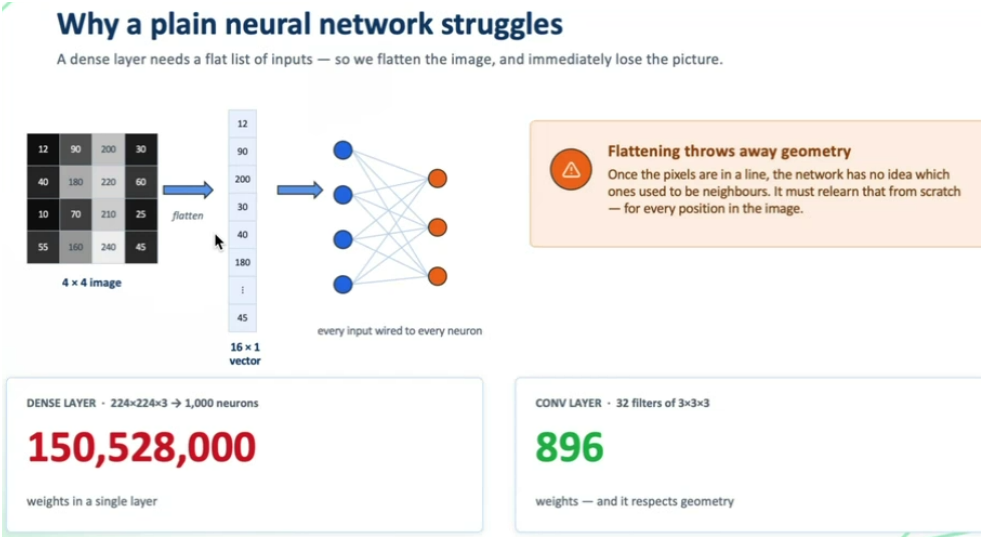

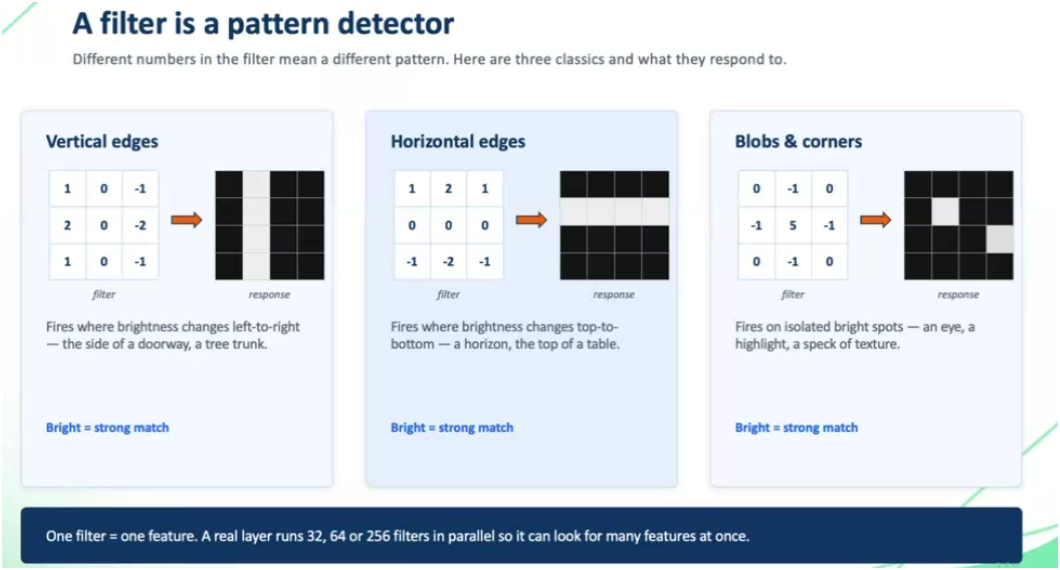

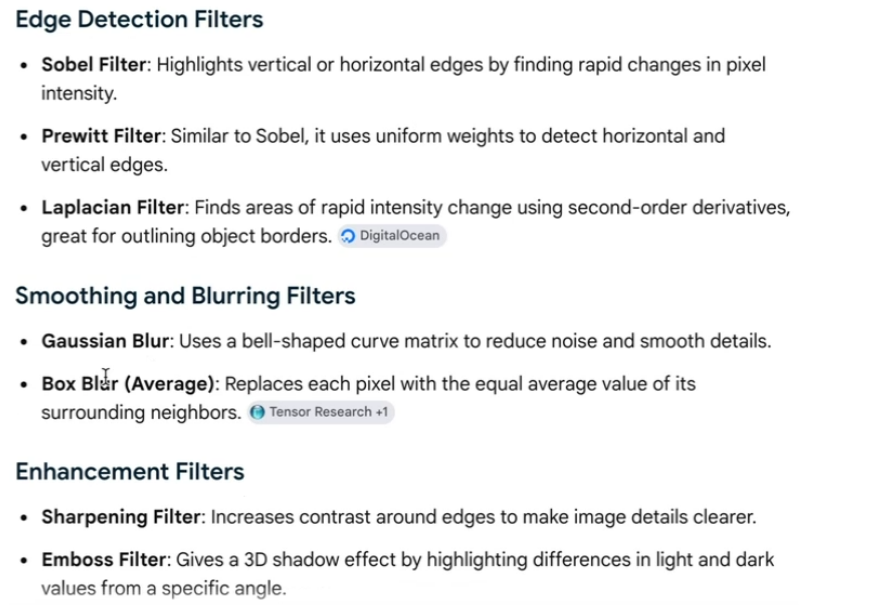

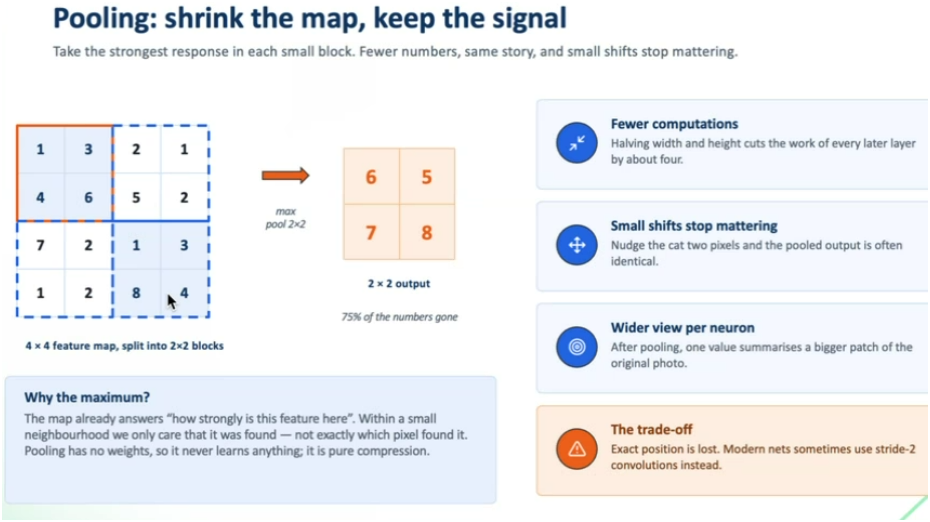

**pooling types**
- max
- averge
- sum

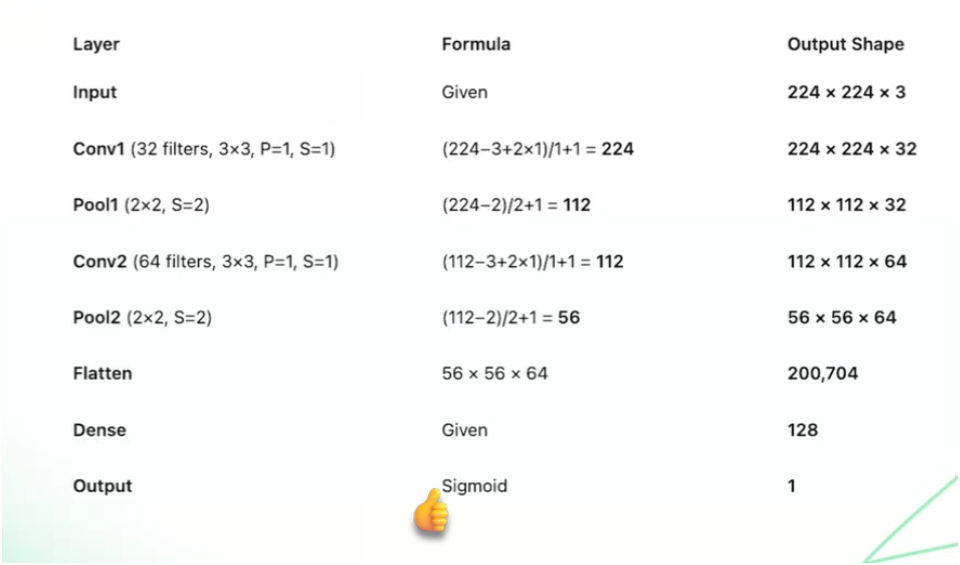

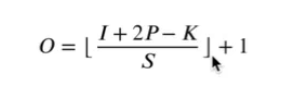

In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [10]:
from tensorflow.keras.datasets import mnist

In [11]:
(X_train,y_train), (X_test,y_test) = mnist.load_data()

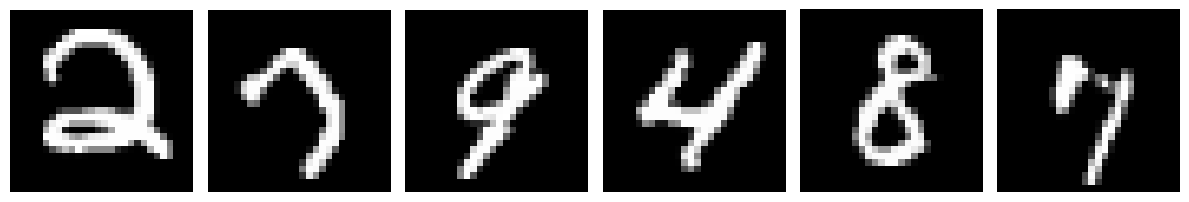

In [12]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(X_train),6,replace = False)
selected_images = [X_train[i] for i in indices]

fig,axes = plt.subplots(1,6, figsize = (12,5))

for ax,img in zip(axes,selected_images):
  ax.imshow(img,cmap = "gray")
  ax.axis("off")

plt.tight_layout()
plt.show()

**Data Processing**

In [13]:
X_train = X_train.reshape(*X_train.shape,1)
X_test = X_test.reshape(*X_test.shape,1)

X_train = X_train / 255
X_test = X_test / 255

"""
  Formula : Normalized_pixel = Pixel / 255.0 (for standard 8-bit images)
"""

'\n  Formula : Normalized_pixel = Pixel / 255.0 (for standard 8-bit images)\n'

In [14]:
input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

In [15]:
model = Sequential()

model.add(Input(shape=(28,28,1)))

model.add(Conv2D(filters = 6, kernel_size=(5,5),strides = (1,1),padding = "valid",activation="relu"))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2))

model.add(Conv2D(filters = 16, kernel_size = (5,5), strides = (1,1), padding = "valid",activation = "relu"))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2))

model.add(Flatten())

model.add(Dense(100,activation = "relu"))
model.add(Dropout(0.25))
model.add(Dense(50,activation = "relu"))
model.add(Dense(num_classes, activation = "softmax"))

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,832 (132.16 KB)

 Trainable params: 33,832 (132.16 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer = "Adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [19]:
history = model.fit(
    X_train, y_train, epochs = 3, batch_size = 64, verbose = 1, validation_split = 0.2
)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9507 - loss: 0.1642 - val_accuracy: 0.9737 - val_loss: 0.0870
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9710 - loss: 0.0951 - val_accuracy: 0.9790 - val_loss: 0.0683
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9773 - loss: 0.0736 - val_accuracy: 0.9828 - val_loss: 0.0589


In [20]:
import pandas as pd
df = pd.DataFrame(history.history)

<Axes: >

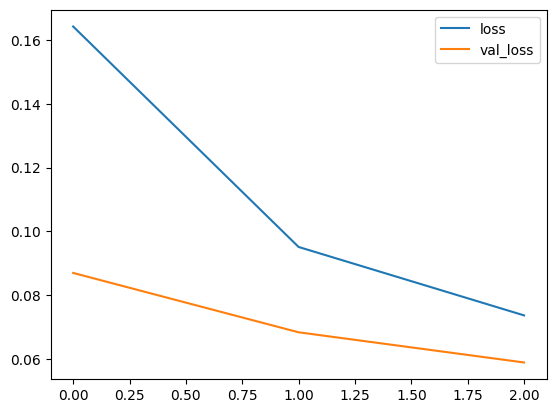

In [21]:
df[["loss","val_loss"]].plot.line()

In [22]:
pred = np.argmax(model.predict(X_test),axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [23]:
from sklearn.metrics import confusion_matrix

In [25]:
confusion_matrix(y_test,pred)

array([[ 978,    0,    0,    0,    0,    0,    1,    1,    0,    0],
       [   0, 1132,    0,    0,    0,    1,    1,    0,    1,    0],
       [   2,    0, 1019,    0,    1,    0,    1,    5,    4,    0],
       [   2,    0,    1,  989,    0,    3,    0,    6,    8,    1],
       [   0,    0,    0,    0,  970,    0,    1,    1,    1,    9],
       [   2,    0,    0,    9,    0,  867,    4,    1,    4,    5],
       [  12,    2,    0,    0,    1,    0,  941,    0,    2,    0],
       [   0,    4,    3,    2,    0,    0,    0, 1017,    2,    0],
       [   5,    0,    1,    1,    1,    0,    3,    1,  961,    1],
       [   3,    7,    0,    5,    7,    1,    0,    9,    3,  974]])